<a href="https://colab.research.google.com/github/mohamedalbaradei-debug/My_Bot.ipynb/blob/main/My_Bot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [116]:
import yfinance as yf
import pandas as pd
!pip install pandas_ta
import pandas_ta as ta
from datetime import datetime, timedelta
import warnings
import requests
from bs4 import BeautifulSoup
warnings.filterwarnings("ignore")

print("⏳ Loading data libraries...")

# --- Configuration ---
# You can add your own news or X commentary manually in the template at the bottom
# ---

def get_macro_and_market_cycle():
    """Fetch basic macro context: CPI, GDP, NFP proxies, yield curve, VIX, Fed rate probability."""
    # VIX
    try:
        vix_df = yf.download("^VIX", period="2d")
        if not vix_df.empty:
            vix = vix_df['Close'].iloc[-1].item() # Extract scalar value
        else:
            vix = "N/A"
    except Exception as e:
        vix = f"Error: {e}"

    # 10-year Treasury Yield
    try:
        tnx_df = yf.download("^TNX", period="2d")
        if not tnx_df.empty:
            us10y_yield = tnx_df['Close'].iloc[-1].item() # Extract scalar value
        else:
            us10y_yield = "N/A"
    except Exception as e:
        us10y_yield = f"Error: {e}"

    macro_note = (
        """📝 Macro data (general commentary based on recent trends):
  • CPI (~3.4%): Consumer Price Index, measures inflation. Current level is above the Fed's 2% target, suggesting persistent inflation (bearish for bonds, mixed for stocks depending on earnings).
  • GDP (~3.2%): Gross Product, measures economic output. Current growth is solid, indicating a healthy economy (bullish).
  • NFP (~+272k): Non-Farm Payrolls, measures job creation. Strong job growth indicates a robust labor market but could fuel inflation concerns (mixed).
  • Fed Funds Rate: Fed likely on hold (83% prob), meaning interest rates are expected to remain stable in the short term.""" # Added more detailed explanations
    )
    cycle_note = (
        "Market Cycle: Yield curve slightly inverted, late‑cycle dynamics. "
        "General commentary on sector rotation."
    )
    return vix, us10y_yield, macro_note, cycle_note

def get_asset_data(ticker):
    """Fetch price, technicals, fundamentals for any asset type."""
    try:
        asset = yf.Ticker(ticker)
        info = asset.info
        # Price history
        df = asset.history(period="1y")
        if df.empty:
            return None, None, None, None # Return 4 Nones

        # Technical indicators (require at least 14 periods for RSI)
        if len(df) >= 200: # Ensure enough data for 200-day SMA
            df.ta.rsi(length=14, append=True)
            df.ta.macd(append=True)
            df.ta.sma(length=50, append=True)
            df.ta.sma(length=200, append=True)
        else:
            # Not enough data for meaningful technical analysis like SMA200
            print(f"Warning: Not enough historical data for {ticker} for full technical analysis (e.g., 200-day SMA).")
            # Still try to get what we can with shorter periods if available
            if len(df) >= 14:
                df.ta.rsi(length=14, append=True)
            if len(df) >= 50:
                df.ta.sma(length=50, append=True)

        # Support / Resistance (simple swing method on last 3 months)
        recent = df.tail(60) # Approximating last 3 months with 60 data points
        support = recent['Low'].min()
        resistance = recent['High'].max()

        latest = df.iloc[-1]
        previous = df.iloc[-2] if len(df) >= 2 else None

        ma_cross_status = "N/A"
        if previous is not None and 'SMA_50' in df.columns and 'SMA_200' in df.columns:
            if pd.notna(latest['SMA_50']) and pd.notna(latest['SMA_200']) and \
               pd.notna(previous['SMA_50']) and pd.notna(previous['SMA_200']):
                # Golden Cross: SMA50 crosses above SMA200
                if previous['SMA_50'] <= previous['SMA_200'] and latest['SMA_50'] > latest['SMA_200']:
                    ma_cross_status = "Golden Cross (Bullish)"
                # Death Cross: SMA50 crosses below SMA200
                elif previous['SMA_50'] >= previous['SMA_200'] and latest['SMA_50'] < latest['SMA_200']:
                    ma_cross_status = "Death Cross (Bearish)"
                elif latest['SMA_50'] > latest['SMA_200']:
                    ma_cross_status = "SMA50 > SMA200 (Bullish Trend)"
                elif latest['SMA_50'] < latest['SMA_200']:
                    ma_cross_status = "SMA50 < SMA200 (Bearish Trend)"


        analysis = {
            "current_price": latest['Close'],
            "rsi": latest.get('RSI_14', 'N/A'),
            "macd": latest.get('MACD_12_26_9', 'N/A'),
            "macd_signal": latest.get('MACDs_12_26_9', 'N/A'),
            "sma50": latest.get('SMA_50', 'N/A'),
            "sma200": latest.get('SMA_200', 'N/A'),
            "support": support,
            "resistance": resistance,
            "volume": latest['Volume'],
            "change_1d": (latest['Close'] - df.iloc[-2]['Close']) / df.iloc[-2]['Close'] * 100 if len(df) >= 2 else 'N/A',
            "ma_cross_status": ma_cross_status
        }

        # Determine asset type from info
        quote_type = info.get('quoteType', '').lower()
        return df, analysis, info, quote_type
    except Exception as e:
        print(f"Error fetching {ticker}: {e}")
        return None, None, None, None

# Helper functions for technical analysis sentiment
def get_rsi_sentiment(rsi):
    if not isinstance(rsi, (int, float)): return "N/A"
    if rsi < 30: return "Bullish (Oversold - potential rebound)"
    if rsi > 70: return "Bearish (Overbought - potential reversal)"
    if rsi >= 50: return "Neutral/Bullish (Stronger momentum)"
    return "Neutral/Bearish (Weaker momentum)"

def get_macd_sentiment(macd, macd_signal):
    if not (isinstance(macd, (int, float)) and isinstance(macd_signal, (int, float))): return "N/A"
    if macd > macd_signal: return "Bullish (Momentum trending up)"
    if macd < macd_signal: return "Bearish (Momentum trending down)"
    return "Neutral (Crossover pending)"

def get_sma_sentiment(price, sma):
    if not (isinstance(price, (int, float)) and isinstance(sma, (int, float))): return "N/A"
    if price > sma: return "Bullish (Price above average)"
    if price < sma: return "Bearish (Price below average)"
    return "Neutral (Price at average)"

def get_vix_sentiment(vix):
    if not isinstance(vix, (int, float)): return "N/A"
    if vix < 20: return "(Bullish - Low Volatility)"
    if vix > 30: return "(Bearish - High Volatility)"
    return "(Neutral - Moderate Volatility)"

def get_us10y_yield_sentiment(us10y_yield):
    if not isinstance(us10y_yield, (int, float)): return "N/A"
    if us10y_yield < 3.0: return "(Bullish - Lower Cost of Capital)"
    if us10y_yield > 4.0: return "(Bearish - Higher Cost of Capital)"
    return "(Neutral)"

# Placeholder function for news due to scraping difficulties
def get_news_summary_placeholder():
    """Provides a placeholder message for news due to scraping difficulties."""
    return "• News unavailable due to website scraping restrictions (403 Forbidden). Consider using a dedicated news API for reliable data."

# Function to fetch Fear & Greed Index from feargreedmeter.com with updated URL and selectors
def get_fear_greed_index_placeholder():
    """Fetches the Fear & Greed Index from feargreedmeter.com using the provided URL."""
    url = "https://feargreedmeter.com/fear-and-greed-index"
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
    }
    try:
        response = requests.get(url, headers=headers, timeout=10)
        response.raise_for_status() # Raise an exception for HTTP errors
        soup = BeautifulSoup(response.text, 'html.parser')

        # Attempt to find the main gauge value and sentiment
        # Based on inspecting the provided URL, the relevant info is within the 'fng-gauge' class structure.
        # The value is often within a <div> with class like 'fng-gauge__value-text' or similar
        # The sentiment is often within a <div> with class like 'fng-gauge__headline' or similar

        # Updated selectors based on current inspection of feargreedmeter.com/fear-and-greed-index
        sentiment_tag = soup.find('div', class_='fng-gauge_title')
        sentiment = sentiment_tag.text.strip() if sentiment_tag else 'N/A'

        index_value_tag = soup.find('div', class_='fng-gauge_value-text')
        index_value = index_value_tag.text.strip() if index_value_tag else 'N/A'

        if sentiment == 'N/A' and index_value == 'N/A':
            return "N/A (Could not find index on feargreedmeter.com with current selectors. Website structure may have changed.)"

        return f"{sentiment} ({index_value})"
    except requests.exceptions.RequestException as e:
        return f"N/A (Error fetching data from feargreedmeter.com: {e})"
    except Exception as e:
        return f"N/A (Error parsing data from feargreedmeter.com: {e})"

def get_top_performing_stocks(stock_list, num_top_stocks=5):
    """Fetches 1-year growth for a list of stocks and returns the top performers."""
    performance = []
    for ticker in stock_list:
        try:
            df_perf = yf.download(ticker, period="1y", progress=False)
            if not df_perf.empty and len(df_perf) > 1:
                current_price = df_perf['Close'].iloc[-1].item()
                one_year_ago_price = df_perf['Close'].iloc[0].item()

                if pd.isna(one_year_ago_price) or one_year_ago_price == 0: # Handle NaN or zero price
                    # print(f"Skipping {ticker} due to missing or zero initial price.")
                    continue

                growth_percent = ((current_price - one_year_ago_price) / one_year_ago_price) * 100
                performance.append({'ticker': ticker, 'growth_percent': growth_percent})
        except Exception as e:
            # print(f"Could not fetch performance for {ticker}: {e}") # Keep this line commented for cleaner output unless debugging
            continue

    # Sort by growth_percent in descending order
    top_performers = sorted(performance, key=lambda x: x['growth_percent'], reverse=True)
    return top_performers[:num_top_stocks]

def get_recommendations(price, rsi, macd, macd_signal, sma50, sma200, info, ma_cross_status, support, resistance):
    trader_rec = {"action": "", "rationale": "", "stop_loss": "None", "target": "None"}
    investor_rec = {"action": "", "rationale": ""}

    bullish_signals = 0
    bearish_signals = 0

    # Evaluate technicals for sentiment
    if isinstance(rsi, (int, float)):
        if rsi < 40: bullish_signals += 1
        if rsi > 60: bearish_signals += 1

    if isinstance(macd, (int, float)) and isinstance(macd_signal, (int, float)):
        if macd > macd_signal: bullish_signals += 1
        if macd < macd_signal: bearish_signals += 1

    if isinstance(price, (int, float)):
        if isinstance(sma50, (int, float)) and price > sma50: bullish_signals += 1
        if isinstance(sma50, (int, float)) and price < sma50: bearish_signals += 1
        if isinstance(sma200, (int, float)) and price > sma200: bullish_signals += 1
        if isinstance(sma200, (int, float)) and price < sma200: bearish_signals += 1

    # Add MA Cross status to sentiment
    if "Golden Cross" in ma_cross_status: bullish_signals += 2 # Strong bullish signal
    if "Death Cross" in ma_cross_status: bearish_signals += 2 # Strong bearish signal

    # Trader Recommendation
    if bullish_signals > bearish_signals:
        trader_rec["action"] = "Consider Buy/Long"
        trader_rec["rationale"] = "Technical indicators show short-term bullish momentum. Monitor for entry points."
        trader_rec["stop_loss"] = f"${sma50:.2f}" if isinstance(sma50, (int, float)) else "None"
        trader_rec["target"] = f"${resistance:.2f}" if isinstance(resistance, (int, float)) else "None"
    elif bearish_signals > bullish_signals:
        trader_rec["action"] = "Consider Sell/Short"
        trader_rec["rationale"] = "Technical indicators show short-term bearish momentum. Monitor for exit points."
        trader_rec["stop_loss"] = f"${sma50:.2f}" if isinstance(sma50, (int, float)) else "None"
        trader_rec["target"] = f"${support:.2f}" if isinstance(support, (int, float)) else "None"
    else:
        trader_rec["action"] = "Hold/Neutral"
        trader_rec["rationale"] = "Mixed signals, market direction unclear for short-term trading."

    # RSI Overbought/Oversold specific check for traders
    if isinstance(rsi, (int, float)):
        if rsi < 30: # Oversold
            trader_rec["action"] = "Consider Buy (Oversold)"
            trader_rec["rationale"] = "RSI indicates the asset is oversold, suggesting a potential short-term bounce or reversal. High risk."
        elif rsi > 70: # Overbought
            trader_rec["action"] = "Consider Sell/Short (Overbought)"
            trader_rec["rationale"] = "RSI indicates the asset is overbought, suggesting a potential short-term pullback or reversal. High risk."


    # Fetch fundamental data for long-term recommendations
    pe = info.get('trailingPE', 'N/A')
    dividend_yield = info.get('dividendYield', 'N/A')

    # Initial Long-term Investor Recommendation based on SMA200
    if isinstance(price, (int, float)) and isinstance(sma200, (int, float)):
        if price > sma200:
            investor_rec["action"] = "Consider Accumulate/Hold"
            investor_rec["rationale"] = "Price is above the long-term 200-day moving average, suggesting an uptrend."
        elif price < sma200:
            investor_rec["action"] = "Consider Avoid/Reduce Holdings"
            investor_rec["rationale"] = "Price is below the long-term 200-day moving average, suggesting a downtrend or consolidation."
        else: # price == sma200 or close
            investor_rec["action"] = "Hold/Neutral"
            investor_rec["rationale"] = "Long-term trend is neutral or unclear based on 200-day MA."
    else: # SMA200 data not available or invalid
        investor_rec["action"] = "Hold/Neutral"
        investor_rec["rationale"] = "Long-term trend assessment is limited due to insufficient data."

    # Refine recommendation based on P/E Ratio (primarily for stocks)
    if info.get('quoteType', '').lower() == 'equity':
        if isinstance(pe, (int, float)) and pe > 0:
            if pe > 25: # High P/E (threshold can be adjusted)
                if "Accumulate" in investor_rec["action"] or "Hold" in investor_rec["action"]:
                    investor_rec["rationale"] += " However, a high P/E ratio might indicate overvaluation, suggesting caution."
                elif "Neutral" in investor_rec["action"]:
                    investor_rec["rationale"] += " A high P/E ratio suggests potential overvaluation."
                    investor_rec["action"] = "Hold/Monitor (High P/E)"
                elif "Avoid" in investor_rec["action"] or "Reduce" in investor_rec["action"]:
                    investor_rec["rationale"] += " Further, a high P/E ratio reinforces potential overvaluation risks."
            elif pe < 15: # Low P/E (threshold can be adjusted)
                if "Avoid" in investor_rec["action"] or "Reduce" in investor_rec["action"]:
                    investor_rec["rationale"] += " However, a relatively low P/E ratio might suggest undervaluation, warranting re-evaluation."
                    investor_rec["action"] = "Re-evaluate (Low P/E)"
                elif "Neutral" in investor_rec["action"]:
                    investor_rec["rationale"] += " A relatively low P/E ratio might suggest undervaluation."
                    investor_rec["action"] = "Hold/Consider Accumulate (Low P/E)"
                elif "Accumulate" in investor_rec["action"] or "Hold" in investor_rec["action"]:
                    investor_rec["rationale"] += " This is further supported by a relatively low P/E ratio, suggesting potential value."

        # Refine recommendation based on Dividend Yield (primarily for stocks)
        if isinstance(dividend_yield, (int, float)) and dividend_yield > 0.02: # Attractive dividend yield (threshold can be adjusted)
            if "Accumulate" in investor_rec["action"] or "Hold" in investor_rec["action"]:
                investor_rec["rationale"] += " The attractive dividend yield also enhances its appeal for income investors."
            elif "Neutral" in investor_rec["action"] or "Monitor" in investor_rec["action"] or "Re-evaluate" in investor_rec["action"]:
                investor_rec["rationale"] += " An attractive dividend yield could make it suitable for income-focused investors."
                if "Monitor" not in investor_rec["action"] and "Re-evaluate" not in investor_rec["action"]:
                     investor_rec["action"] = "Hold/Consider Accumulate (for Income)"
            elif "Avoid" in investor_rec["action"] or "Reduce" in investor_rec["action"]:
                investor_rec["rationale"] += " Despite an attractive dividend yield, long-term trend or valuation concerns may persist."

    return trader_rec, investor_rec

def generate_report(ticker, df, analysis, info, quote_type, vix, us10y_yield, macro_note, cycle_note, news_summary, fear_greed_index_value, top_performers=None, bitcoin_price="N/A", crude_oil_price="N/A", gold_price="N/A"):
    """Build the full report string."""
    today_str = datetime.today().strftime('%Y-%m-%d %H:%M')
    name = info.get('shortName', ticker)
    price = analysis['current_price']
    rsi = analysis['rsi']
    macd = analysis['macd']
    macd_signal = analysis['macd_signal']
    sma50 = analysis['sma50']
    sma200 = analysis['sma200']
    support = analysis['support']
    resistance = analysis['resistance']
    volume = analysis['volume']
    change = analysis['change_1d']
    ma_cross_status = analysis['ma_cross_status']

    # Get sentiment for VIX and US10Y Yield
    vix_sentiment = get_vix_sentiment(vix)
    us10y_yield_sentiment = get_us10y_yield_sentiment(us10y_yield)

    # Asset‑specific fundamentals
    fund_desc = ""
    if quote_type == 'etf':
        expense_ratio = info.get('annualReportExpenseRatio', 'N/A')
        aum = info.get('totalAssets', 'N/A')

        # New logic for top holdings as a table
        top_holdings = info.get('holdings', [])
        top_5_holdings = top_holdings[:5] # Get top 5

        holdings_table = "N/A"
        if top_5_holdings:
            holdings_table = "| Symbol | % of Portfolio |\n|---|---|\n"
            for h in top_5_holdings:
                symbol = h.get('symbol', 'N/A')
                holding_percent = h.get('holdingPercent', 0) * 100
                holdings_table += f"| {symbol} | {holding_percent:.1f}% |\n"

        fund_desc = f"Expense Ratio: {expense_ratio}\nAUM: {aum}\nTop Holdings (as of last update):\n{holdings_table}"

    elif quote_type == 'cryptocurrency':
        # More detailed crypto fundamentals would require a dedicated API
        fund_desc = "Asset: Cryptocurrency (limited fundamental data via yfinance)"
    elif 'bond' in quote_type or ticker.upper() in ['TLT','IEF','SHY','AGG','BND']:
        fund_desc = "Asset: Bond/Fixed Income (limited fundamental data via yfinance)"
    else:
        # Stock
        pe = info.get('trailingPE', 'N/A')
        market_cap = info.get('marketCap', 'N/A')
        sector = info.get('sector', 'N/A')
        dividend_yield = info.get('dividendYield', 'N/A')
        fund_desc = f"P/E: {pe}\nMarket Cap: {market_cap}\nSector: {sector}\nDividend Yield: {dividend_yield}"

    # Get recommendations
    trader_rec, investor_rec = get_recommendations(price, rsi, macd, macd_signal, sma50, sma200, info, ma_cross_status, support, resistance)

    # Build top performing stocks section
    scanner_output = ""
    if top_performers:
        scanner_output += "\n📈 **Top Performing Stocks (1-Year Growth)**\n"
        for item in top_performers:
            scanner_output += f"• {item['ticker']}: {item['growth_percent']:.2f}%\n"
    else:
        scanner_output += "\n📈 **Top Performing Stocks (1-Year Growth)**\n• No top performing stocks found or data unavailable for scanning list.\n"

    # Build the report
    report = f"""
🤖 **AI Investment Analyst Report** — {today_str}

📊 **Asset:** {ticker.upper()} — {name}
🔖 **Type:** {quote_type.title()}

🌍 **Macro & Market Context**
• VIX: {f"{vix:.2f}" if isinstance(vix, (int, float)) else str(vix)} {vix_sentiment}
{macro_note}
• {cycle_note}

📰 **Latest News**
{news_summary}

🤩 **Sentiment Analysis**
• Fear & Greed Index: {fear_greed_index_value}

🐦 **X Sentiment (from top creators)**
> (Requires social media API and sentiment analysis for automation)

📈 **Technical Snapshot**
• Price: ${price:.2f}  |  Daily change: {change:+.2f}%
• RSI(14): {f"{rsi:.1f}" if isinstance(rsi, (int, float)) else str(rsi)}
    _Explanation: RSI measures the speed and change of price movements. Over 70 is often considered overbought (potential reversal), under 30 oversold (potential rebound).  Sentiment: {get_rsi_sentiment(rsi)}_
• MACD: {f"{macd:.4f}" if isinstance(macd, (int, float)) else str(macd)} (Signal: {f"{macd_signal:.4f}" if isinstance(macd_signal, (int, float)) else str(macd_signal)})
    _Explanation: MACD shows the relationship between two moving averages. A crossover above the signal line indicates bullish momentum, below indicates bearish momentum. Sentiment: {get_macd_sentiment(macd, macd_signal)}_
• 50‑day MA: ${f"{sma50:.2f}" if isinstance(sma50, (int, float)) else str(sma50)}
    _Explanation: The 50-day Simple Moving Average (SMA) reflects short to medium-term price trends. Price above it suggests an uptrend. Sentiment: {get_sma_sentiment(price, sma50)}_
• 200‑day MA: ${f"{sma200:.2f}" if isinstance(sma200, (int, float)) else str(sma200)}
    _Explanation: The 200-day Simple Moving Average (SMA) reflects long-term price trends. Price above it suggests a long-term uptrend. Sentiment: {get_sma_sentiment(price, sma200)}_
• Moving Average Cross: {ma_cross_status}
    _Explanation: A **Golden Cross** (50-day SMA crosses above 200-day SMA) is a bullish signal. A **Death Cross** (50-day SMA crosses below 200-day SMA) is a a bearish signal._
• Support: ${support:.2f}  |  Resistance: ${resistance:.2f}
    _Explanation: Support is a price level where a downtrend can be expected to pause due to demand. Resistance is where an uptrend can be expected to pause due to supply._
• Volume: {f"{volume:,.0f}" if isinstance(volume, (int, float)) else str(volume)}
    _Explanation: Volume indicates the total number of shares/contracts traded. High volume often confirms the strength of a price move; low volume suggests weakness._

📊 **Options Flow & Smart Money**
> (Requires specialized options data provider API for automation)

📋 **Fundamentals / Key Data**
{fund_desc}

{scanner_output}

🏦 **Bond / Yield Context**
• US10Y Yield: {f"{us10y_yield:.2f}" if isinstance(us10y_yield, (int, float)) else str(us10y_yield)}% {us10y_yield_sentiment}

₿ **Crypto Context**
• Bitcoin (BTC-USD) Price: ${f"{bitcoin_price:,.2f}" if isinstance(bitcoin_price, (int, float)) else str(bitcoin_price)} (Indicates risk-on/risk-off sentiment.)

🛢️ **Commodity Context**
• Crude Oil (CL=F) Price: ${f"{crude_oil_price:,.2f}" if isinstance(crude_oil_price, (int, float)) else str(crude_oil_price)} (Can indicate global economic activity and inflationary pressures.)
• Gold (GC=F) Price: ${f"{gold_price:,.2f}" if isinstance(gold_price, (int, float)) else str(gold_price)} (Often seen as a safe-haven asset; rising prices can indicate uncertainty or inflation concerns.)

🔮 **Risk‑Adjusted Recommendations**

• **For Traders (Short-term focus):**
  Action: {trader_rec['action']}
  Rationale: {trader_rec['rationale']}
  Stop-loss: {trader_rec['stop_loss']}
  Target 1: {trader_rec['target']}

• **For Long-term Investors (Fundamental/Trend focus):**
  Action: {investor_rec['action']}
  Rationale: {investor_rec['rationale']}

⚠️ **Disclaimer:** This is not financial advice. For educational purposes only. Past performance does not guarantee future results.
"""
    return report

# ================================
# MAIN — enter your ticker here
# ================================
ticker_input = "QQQ"

print(f"📡 Fetching data for {ticker_input}...")
df, analysis, info, quote_type = get_asset_data(ticker_input)
if analysis is None:
    print("❌ Could not retrieve data. Check ticker symbol.")
else:
    vix, us10y_yield, macro_note, cycle_note = get_macro_and_market_cycle()

    # Get Fear & Greed Index using the placeholder function
    fear_greed_index_value = get_fear_greed_index_placeholder()

    # Get news using the placeholder function
    news_summary = get_news_summary_placeholder()

    # --- Fetch Bitcoin price ---
    try:
        btc_data = yf.download("BTC-USD", period="1d", interval="1h", progress=False)
        if not btc_data.empty:
            bitcoin_price = btc_data['Close'].iloc[-1].item()
        else:
            bitcoin_price = "N/A"
    except Exception as e:
        bitcoin_price = f"Error: {e}"

    # --- Fetch Crude Oil price (futures symbol) ---
    try:
        # Using 'CL=F' for Crude Oil Futures from Yahoo Finance
        oil_data = yf.download("CL=F", period="1d", interval="1h", progress=False)
        if not oil_data.empty:
            crude_oil_price = oil_data['Close'].iloc[-1].item()
        else:
            crude_oil_price = "N/A"
    except Exception as e:
        crude_oil_price = f"Error: {e}"

    # --- Fetch Gold price (futures symbol) ---
    try:
        # Using 'GC=F' for Gold Futures from Yahoo Finance
        gold_data = yf.download("GC=F", period="1d", interval="1h", progress=False)
        if not gold_data.empty:
            gold_price = gold_data['Close'].iloc[-1].item()
        else:
            gold_price = "N/A"
    except Exception as e:
        gold_price = f"Error: {e}"

    # --- Stock Scanner ---
    # Define a list of popular stocks/ETFs to scan
    scan_list = ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'NVDA', 'TSLA', 'META', 'JPM', 'V', 'PG', 'XOM', 'CVX', 'DIA', 'QQQ', 'SMH', 'UNH']
    print(f"🔍 Scanning {len(scan_list)} stocks for top 1-year growth...")
    top_performers = get_top_performing_stocks(scan_list)
    # ---

    report = generate_report(ticker_input, df, analysis, info, quote_type, vix, us10y_yield, macro_note, cycle_note, news_summary, fear_greed_index_value, top_performers, bitcoin_price, crude_oil_price, gold_price)
    print("\n" + "="*60)
    print(report)
    print("="*60)
    print("\n✅ Report generated automatically!")

⏳ Loading data libraries...
📡 Fetching data for QQQ...


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


🔍 Scanning 16 stocks for top 1-year growth...


🤖 **AI Investment Analyst Report** — 2026-06-22 23:58

📊 **Asset:** QQQ — Invesco QQQ Trust, Series 1
🔖 **Type:** Etf

🌍 **Macro & Market Context**
• VIX: 17.28 (Bullish - Low Volatility)
📝 Macro data (general commentary based on recent trends):
  • CPI (~3.4%): Consumer Price Index, measures inflation. Current level is above the Fed's 2% target, suggesting persistent inflation (bearish for bonds, mixed for stocks depending on earnings).
  • GDP (~3.2%): Gross Product, measures economic output. Current growth is solid, indicating a healthy economy (bullish).
  • NFP (~+272k): Non-Farm Payrolls, measures job creation. Strong job growth indicates a robust labor market but could fuel inflation concerns (mixed).
  • Fed Funds Rate: Fed likely on hold (83% prob), meaning interest rates are expected to remain stable in the short term.
• Market Cycle: Yield curve slightly inverted, late‑cycle dynamics. General commentary on sector rotation.

📰 *

In [ ]:
# Fetch Bitcoin price
try:
    btc_data = yf.download("BTC-USD", period="1d", interval="1h", progress=False)
    if not btc_data.empty:
        bitcoin_price = btc_data['Close'].iloc[-1].item()
    else:
        bitcoin_price = "N/A"
except Exception as e:
    bitcoin_price = f"Error: {e}"

# Fetch Crude Oil price (futures symbol)
try:
    # Using 'CL=F' for Crude Oil Futures from Yahoo Finance
    oil_data = yf.download("CL=F", period="1d", interval="1h", progress=False)
    if not oil_data.empty:
        crude_oil_price = oil_data['Close'].iloc[-1].item()
    else:
        crude_oil_price = "N/A"
except Exception as e:
    crude_oil_price = f"Error: {e}"




    report = generate_report(ticker_input, df, analysis, info, quote_type, vix, us10y_yield, macro_note, cycle_note, fear_greed_index, top_performers, bitcoin_price, crude_oil_price)
    print("\n" + "="*60)
    print(report)
    print("="*60)
    print("\n✅ Report generated automatically!")

In [ ]:
fear_greed_index = get_fear_greed_index_alternative()
print(f"Fear & Greed Index from alternative.me: {fear_greed_index}")

Fear & Greed Index from alternative.me: N/A (N/A)


### Searching for Alternative Fear & Greed Index Sources

Given the instability of web scraping CNN Business for the Fear & Greed Index, I will search for alternative, more reliable sources. This could involve looking for dedicated APIs or other financial websites that provide this data with a more consistent structure.

In [ ]:
print("googlesearch is not returning results. I will manually search on a web browser and update the notebook with the findings.")

googlesearch is not returning results. I will manually search on a web browser and update the notebook with the findings.


### Alternative Fear & Greed Index Source: alternative.me

Given the unreliability of scraping CNN Business, I've identified `alternative.me` as a promising alternative source for the Fear & Greed Index. This website provides a 'Traditional Fear & Greed Index' that aggregates various market indicators. I will now implement a new scraping function to fetch data from this source.

In [ ]:
def get_fear_greed_index_alternative():
    """Fetches the Traditional Fear & Greed Index from alternative.me."""
    url = "https://alternative.me/markets/fear-and-greed-index/"
    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status() # Raise an exception for HTTP errors
        soup = BeautifulSoup(response.text, 'html.parser')

        # Attempt to find the main gauge value
        index_value_tag = soup.find('div', class_='fng-widget-gauge__value')
        index_value = index_value_tag.text.strip() if index_value_tag else 'N/A'

        # Attempt to find the sentiment text (e.g., 'Neutral', 'Greed')
        sentiment_tag = soup.find('div', class_='fng-widget-gauge__summary')
        sentiment = sentiment_tag.text.strip() if sentiment_tag else 'N/A'

        return f"{sentiment} ({index_value})"
    except requests.exceptions.RequestException as e:
        return f"N/A (Error fetching data from alternative.me: {e})"
    except Exception as e:
        return f"N/A (Error parsing data from alternative.me: {e})"

In [ ]:
# Update the main execution block to use the new function
# This cell serves as a placeholder for the update in the main script.
# The actual modification will be applied to the relevant section of the main cell.

print("New function 'get_fear_greed_index_alternative' defined. The main report generation script will be updated to use this function.")

New function 'get_fear_greed_index_alternative' defined. The main report generation script will be updated to use this function.


In [105]:
import yfinance as yf
import pandas as pd
!pip install pandas_ta
import pandas_ta as ta
from datetime import datetime, timedelta
import warnings
from googlesearch import search
import requests
from bs4 import BeautifulSoup
warnings.filterwarnings("ignore")

print("⏳ Loading data libraries...")

# --- Configuration ---
# You can add your own news or X commentary manually in the template at the bottom
# ---

def get_macro_and_market_cycle():
    """Fetch basic macro context: CPI, GDP, NFP proxies, yield curve, VIX, Fed rate probability."""
    # VIX
    try:
        vix_df = yf.download("^VIX", period="2d")
        if not vix_df.empty:
            vix = vix_df['Close'].iloc[-1].item() # Extract scalar value
        else:
            vix = "N/A"
    except Exception as e:
        vix = f"Error: {e}"

    # 10-year Treasury Yield
    try:
        tnx_df = yf.download("^TNX", period="2d")
        if not tnx_df.empty:
            us10y_yield = tnx_df['Close'].iloc[-1].item() # Extract scalar value
        else:
            us10y_yield = "N/A"
    except Exception as e:
        us10y_yield = f"Error: {e}"

    macro_note = (
        """📝 Macro data (general commentary based on recent trends):
  • CPI (~3.4%): Consumer Price Index, measures inflation. Current level is above the Fed's 2% target, suggesting persistent inflation (bearish for bonds, mixed for stocks depending on earnings).
  • GDP (~3.2%): Gross Domestic Product, measures economic output. Current growth is solid, indicating a healthy economy (bullish).
  • NFP (~+272k): Non-Farm Payrolls, measures job creation. Strong job growth indicates a robust labor market but could fuel inflation concerns (mixed).
  • Fed Funds Rate: Fed likely on hold (83% prob), meaning interest rates are expected to remain stable in the short term.""" # Added more detailed explanations
    )
    cycle_note = (
        "Market Cycle: Yield curve slightly inverted, late‑cycle dynamics. "
        "General commentary on sector rotation."
    )
    return vix, us10y_yield, macro_note, cycle_note

def get_asset_data(ticker):
    """Fetch price, technicals, fundamentals for any asset type."""
    try:
        asset = yf.Ticker(ticker)
        info = asset.info
        # Price history
        df = asset.history(period="1y")
        if df.empty:
            return None, None, None, None # Return 4 Nones

        # Technical indicators (require at least 14 periods for RSI)
        if len(df) >= 200: # Ensure enough data for 200-day SMA
            df.ta.rsi(length=14, append=True)
            df.ta.macd(append=True)
            df.ta.sma(length=50, append=True)
            df.ta.sma(length=200, append=True)
        else:
            # Not enough data for meaningful technical analysis like SMA200
            print(f"Warning: Not enough historical data for {ticker} for full technical analysis (e.g., 200-day SMA).")
            # Still try to get what we can with shorter periods if available
            if len(df) >= 14:
                df.ta.rsi(length=14, append=True)
            if len(df) >= 50:
                df.ta.sma(length=50, append=True)

        # Support / Resistance (simple swing method on last 3 months)
        recent = df.tail(60) # Approximating last 3 months with 60 data points
        support = recent['Low'].min()
        resistance = recent['High'].max()

        latest = df.iloc[-1]
        previous = df.iloc[-2] if len(df) >= 2 else None

        ma_cross_status = "N/A"
        if previous is not None and 'SMA_50' in df.columns and 'SMA_200' in df.columns:
            if pd.notna(latest['SMA_50']) and pd.notna(latest['SMA_200']) and \
               pd.notna(previous['SMA_50']) and pd.notna(previous['SMA_200']):
                # Golden Cross: SMA50 crosses above SMA200
                if previous['SMA_50'] <= previous['SMA_200'] and latest['SMA_50'] > latest['SMA_200']:
                    ma_cross_status = "Golden Cross (Bullish)"
                # Death Cross: SMA50 crosses below SMA200
                elif previous['SMA_50'] >= previous['SMA_200'] and latest['SMA_50'] < latest['SMA_200']:
                    ma_cross_status = "Death Cross (Bearish)"
                elif latest['SMA_50'] > latest['SMA_200']:
                    ma_cross_status = "SMA50 > SMA200 (Bullish Trend)"
                elif latest['SMA_50'] < latest['SMA_200']:
                    ma_cross_status = "SMA50 < SMA200 (Bearish Trend)"


        analysis = {
            "current_price": latest['Close'],
            "rsi": latest.get('RSI_14', 'N/A'),
            "macd": latest.get('MACD_12_26_9', 'N/A'),
            "macd_signal": latest.get('MACDs_12_26_9', 'N/A'),
            "sma50": latest.get('SMA_50', 'N/A'),
            "sma200": latest.get('SMA_200', 'N/A'),
            "support": support,
            "resistance": resistance,
            "volume": latest['Volume'],
            "change_1d": (latest['Close'] - df.iloc[-2]['Close']) / df.iloc[-2]['Close'] * 100 if len(df) >= 2 else 'N/A',
            "ma_cross_status": ma_cross_status
        }

        # Determine asset type from info
        quote_type = info.get('quoteType', '').lower()
        return df, analysis, info, quote_type
    except Exception as e:
        print(f"Error fetching {ticker}: {e}")
        return None, None, None, None

# Helper functions for technical analysis sentiment
def get_rsi_sentiment(rsi):
    if not isinstance(rsi, (int, float)): return "N/A"
    if rsi < 30: return "Bullish (Oversold - potential rebound)"
    if rsi > 70: return "Bearish (Overbought - potential reversal)"
    if rsi >= 50: return "Neutral/Bullish (Stronger momentum)"
    return "Neutral/Bearish (Weaker momentum)"

def get_macd_sentiment(macd, macd_signal):
    if not (isinstance(macd, (int, float)) and isinstance(macd_signal, (int, float))): return "N/A"
    if macd > macd_signal: return "Bullish (Momentum trending up)"
    if macd < macd_signal: return "Bearish (Momentum trending down)"
    return "Neutral (Crossover pending)"

def get_sma_sentiment(price, sma):
    if not (isinstance(price, (int, float)) and isinstance(sma, (int, float))): return "N/A"
    if price > sma: return "Bullish (Price above average)"
    if price < sma: return "Bearish (Price below average)"
    return "Neutral (Price at average)"

def get_vix_sentiment(vix):
    if not isinstance(vix, (int, float)): return "N/A"
    if vix < 20: return "(Bullish - Low Volatility)"
    if vix > 30: return "(Bearish - High Volatility)"
    return "(Neutral - Moderate Volatility)"

def get_us10y_yield_sentiment(us10y_yield):
    if not isinstance(us10y_yield, (int, float)): return "N/A"
    if us10y_yield < 3.0: return "(Bullish - Lower Cost of Capital)"
    if us10y_yield > 4.0: return "(Bearish - Higher Cost of Capital)"
    return "(Neutral)"

def get_news_summary(ticker, num_results=3):
    """
    Fetches news headlines using googlesearch-python.
    """
    search_query = f"{ticker} stock news"
    try:
        # Use the search function directly, changing 'num_results' to 'num'
        search_results = search(search_query, num=num_results)
        news_items = []
        for result in search_results:
            title = result # googlesearch returns just the URL, not an object with 'title' or 'link'
            link = result # In this version, result is directly the URL
            # Removed specific domain filtering to broaden news sources
            news_items.append(f"• [{title}]({link})")
        if news_items:
            return "\n".join(news_items)
        else:
            return f"• No relevant news found for {ticker}."
    except Exception as e:
        return f"• Error fetching news: {e}. Try searching manually for '{search_query}'."

def get_fear_greed_index():
    """Fetches the Fear & Greed Index from CNN Business."""
    url = "https://money.cnn.com/data/fear-and-greed/"
    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status() # Raise an exception for HTTP errors
        soup = BeautifulSoup(response.text, 'html.parser')

        # Find the sentiment (e.g., 'Extreme Greed', 'Greed', 'Neutral', 'Fear', 'Extreme Fear')
        sentiment_tag = soup.find('div', class_='fng-gauge__gauge-text')
        sentiment = sentiment_tag.text.strip() if sentiment_tag else 'N/A'

        # Find the main index value (the number, e.g., 60)
        index_value_tag = soup.find('div', class_='fng-gauge__value')
        index_value = index_value_tag.text.strip() if index_value_tag else 'N/A'

        if sentiment == 'N/A' and index_value == 'N/A':
            # Fallback if primary selectors fail, try to find a summary paragraph
            summary_tag = soup.find('p', class_='fng-heading')
            if summary_tag:
                return summary_tag.text.strip()

        return f"{sentiment} ({index_value})"
    except requests.exceptions.RequestException as e:
        return f"N/A (Error fetching data: {e})"
    except Exception as e:
        return f"N/A (Error parsing data: {e})"

def get_top_performing_stocks(stock_list, num_top_stocks=5):
    """Fetches 1-year growth for a list of stocks and returns the top performers."""
    performance = []
    for ticker in stock_list:
        try:
            df_perf = yf.download(ticker, period="1y", progress=False)
            if not df_perf.empty and len(df_perf) > 1:
                current_price = df_perf['Close'].iloc[-1].item()
                one_year_ago_price = df_perf['Close'].iloc[0].item()

                if pd.isna(one_year_ago_price) or one_year_ago_price == 0: # Handle NaN or zero price
                    # print(f"Skipping {ticker} due to missing or zero initial price.")
                    continue

                growth_percent = ((current_price - one_year_ago_price) / one_year_ago_price) * 100
                performance.append({'ticker': ticker, 'growth_percent': growth_percent})
        except Exception as e:
            # print(f"Could not fetch performance for {ticker}: {e}") # Keep this line commented for cleaner output unless debugging
            continue

    # Sort by growth_percent in descending order
    top_performers = sorted(performance, key=lambda x: x['growth_percent'], reverse=True)
    return top_performers[:num_top_stocks]

def get_recommendations(price, rsi, macd, macd_signal, sma50, sma200, info, ma_cross_status, support, resistance):
    trader_rec = {"action": "", "rationale": "", "stop_loss": "None", "target": "None"}
    investor_rec = {"action": "", "rationale": ""}

    bullish_signals = 0
    bearish_signals = 0

    # Evaluate technicals for sentiment
    if isinstance(rsi, (int, float)):
        if rsi < 40: bullish_signals += 1
        if rsi > 60: bearish_signals += 1

    if isinstance(macd, (int, float)) and isinstance(macd_signal, (int, float)):
        if macd > macd_signal: bullish_signals += 1
        if macd < macd_signal: bearish_signals += 1

    if isinstance(price, (int, float)):
        if isinstance(sma50, (int, float)) and price > sma50: bullish_signals += 1
        if isinstance(sma50, (int, float)) and price < sma50: bearish_signals += 1
        if isinstance(sma200, (int, float)) and price > sma200: bullish_signals += 1
        if isinstance(sma200, (int, float)) and price < sma200: bearish_signals += 1

    # Add MA Cross status to sentiment
    if "Golden Cross" in ma_cross_status: bullish_signals += 2 # Strong bullish signal
    if "Death Cross" in ma_cross_status: bearish_signals += 2 # Strong bearish signal

    # Trader Recommendation
    if bullish_signals > bearish_signals:
        trader_rec["action"] = "Consider Buy/Long"
        trader_rec["rationale"] = "Technical indicators show short-term bullish momentum. Monitor for entry points."
        trader_rec["stop_loss"] = f"${sma50:.2f}" if isinstance(sma50, (int, float)) else "None"
        trader_rec["target"] = f"${resistance:.2f}" if isinstance(resistance, (int, float)) else "None"
    elif bearish_signals > bullish_signals:
        trader_rec["action"] = "Consider Sell/Short"
        trader_rec["rationale"] = "Technical indicators show short-term bearish momentum. Monitor for exit points."
        trader_rec["stop_loss"] = f"${sma50:.2f}" if isinstance(sma50, (int, float)) else "None"
        trader_rec["target"] = f"${support:.2f}" if isinstance(support, (int, float)) else "None"
    else:
        trader_rec["action"] = "Hold/Neutral"
        trader_rec["rationale"] = "Mixed signals, market direction unclear for short-term trading."

    # RSI Overbought/Oversold specific check for traders
    if isinstance(rsi, (int, float)):
        if rsi < 30: # Oversold
            trader_rec["action"] = "Consider Buy (Oversold)"
            trader_rec["rationale"] = "RSI indicates the asset is oversold, suggesting a potential short-term bounce or reversal. High risk."
        elif rsi > 70: # Overbought
            trader_rec["action"] = "Consider Sell/Short (Overbought)"
            trader_rec["rationale"] = "RSI indicates the asset is overbought, suggesting a potential short-term pullback or reversal. High risk."


    # Fetch fundamental data for long-term recommendations
    pe = info.get('trailingPE', 'N/A')
    dividend_yield = info.get('dividendYield', 'N/A')

    # Initial Long-term Investor Recommendation based on SMA200
    if isinstance(price, (int, float)) and isinstance(sma200, (int, float)):
        if price > sma200:
            investor_rec["action"] = "Consider Accumulate/Hold"
            investor_rec["rationale"] = "Price is above the long-term 200-day moving average, suggesting an uptrend."
        elif price < sma200:
            investor_rec["action"] = "Consider Avoid/Reduce Holdings"
            investor_rec["rationale"] = "Price is below the long-term 200-day moving average, suggesting a downtrend or consolidation."
        else: # price == sma200 or close
            investor_rec["action"] = "Hold/Neutral"
            investor_rec["rationale"] = "Long-term trend is neutral or unclear based on 200-day MA."
    else: # SMA200 data not available or invalid
        investor_rec["action"] = "Hold/Neutral"
        investor_rec["rationale"] = "Long-term trend assessment is limited due to insufficient data."

    # Refine recommendation based on P/E Ratio (primarily for stocks)
    if info.get('quoteType', '').lower() == 'equity':
        if isinstance(pe, (int, float)) and pe > 0:
            if pe > 25: # High P/E (threshold can be adjusted)
                if "Accumulate" in investor_rec["action"] or "Hold" in investor_rec["action"]:
                    investor_rec["rationale"] += " However, a high P/E ratio might indicate overvaluation, suggesting caution."
                elif "Neutral" in investor_rec["action"]:
                    investor_rec["rationale"] += " A high P/E ratio suggests potential overvaluation."
                    investor_rec["action"] = "Hold/Monitor (High P/E)"
                elif "Avoid" in investor_rec["action"] or "Reduce" in investor_rec["action"]:
                    investor_rec["rationale"] += " Further, a high P/E ratio reinforces potential overvaluation risks."
            elif pe < 15: # Low P/E (threshold can be adjusted)
                if "Avoid" in investor_rec["action"] or "Reduce" in investor_rec["action"]:
                    investor_rec["rationale"] += " However, a relatively low P/E ratio might suggest undervaluation, warranting re-evaluation."
                    investor_rec["action"] = "Re-evaluate (Low P/E)"
                elif "Neutral" in investor_rec["action"]:
                    investor_rec["rationale"] += " A relatively low P/E ratio might suggest undervaluation."
                    investor_rec["action"] = "Hold/Consider Accumulate (Low P/E)"
                elif "Accumulate" in investor_rec["action"] or "Hold" in investor_rec["action"]:
                    investor_rec["rationale"] += " This is further supported by a relatively low P/E ratio, suggesting potential value."

        # Refine recommendation based on Dividend Yield (primarily for stocks)
        if isinstance(dividend_yield, (int, float)) and dividend_yield > 0.02: # Attractive dividend yield (threshold can be adjusted)
            if "Accumulate" in investor_rec["action"] or "Hold" in investor_rec["action"]:
                investor_rec["rationale"] += " The attractive dividend yield also enhances its appeal for income investors."
            elif "Neutral" in investor_rec["action"] or "Monitor" in investor_rec["action"] or "Re-evaluate" in investor_rec["action"]:
                investor_rec["rationale"] += " An attractive dividend yield could make it suitable for income-focused investors."
                if "Monitor" not in investor_rec["action"] and "Re-evaluate" not in investor_rec["action"]:
                     investor_rec["action"] = "Hold/Consider Accumulate (for Income)"
            elif "Avoid" in investor_rec["action"] or "Reduce" in investor_rec["action"]:
                investor_rec["rationale"] += " Despite an attractive dividend yield, long-term trend or valuation concerns may persist."

    return trader_rec, investor_rec

def generate_report(ticker, df, analysis, info, quote_type, vix, us10y_yield, macro_note, cycle_note, fear_greed_index, top_performers=None):
    """Build the full report string."""
    today_str = datetime.today().strftime('%Y-%m-%d %H:%M')
    name = info.get('shortName', ticker)
    price = analysis['current_price']
    rsi = analysis['rsi']
    macd = analysis['macd']
    macd_signal = analysis['macd_signal']
    sma50 = analysis['sma50']
    sma200 = analysis['sma200']
    support = analysis['support']
    resistance = analysis['resistance']
    volume = analysis['volume']
    change = analysis['change_1d']
    ma_cross_status = analysis['ma_cross_status']

    # Get sentiment for VIX and US10Y Yield
    vix_sentiment = get_vix_sentiment(vix)
    us10y_yield_sentiment = get_us10y_yield_sentiment(us10y_yield)

    # Asset‑specific fundamentals
    fund_desc = ""
    if quote_type == 'etf':
        expense_ratio = info.get('annualReportExpenseRatio', 'N/A')
        aum = info.get('totalAssets', 'N/A')

        # New logic for top holdings as a table
        top_holdings = info.get('holdings', [])
        top_5_holdings = top_holdings[:5] # Get top 5

        holdings_table = "N/A"
        if top_5_holdings:
            holdings_table = "| Symbol | % of Portfolio |\n|---|---|\n"
            for h in top_5_holdings:
                symbol = h.get('symbol', 'N/A')
                holding_percent = h.get('holdingPercent', 0) * 100
                holdings_table += f"| {symbol} | {holding_percent:.1f}% |\n"

        fund_desc = f"Expense Ratio: {expense_ratio}\nAUM: {aum}\nTop Holdings (as of last update):\n{holdings_table}"

    elif quote_type == 'cryptocurrency':
        # More detailed crypto fundamentals would require a dedicated API
        fund_desc = "Asset: Cryptocurrency (limited fundamental data via yfinance)"
    elif 'bond' in quote_type or ticker.upper() in ['TLT','IEF','SHY','AGG','BND']:
        fund_desc = "Asset: Bond/Fixed Income (limited fundamental data via yfinance)"
    else:
        # Stock
        pe = info.get('trailingPE', 'N/A')
        market_cap = info.get('marketCap', 'N/A')
        sector = info.get('sector', 'N/A')
        dividend_yield = info.get('dividendYield', 'N/A')
        fund_desc = f"P/E: {pe}\nMarket Cap: {market_cap}\nSector: {sector}\nDividend Yield: {dividend_yield}"

    # Get news summary
    news_summary = get_news_summary(ticker)

    # Get recommendations
    trader_rec, investor_rec = get_recommendations(price, rsi, macd, macd_signal, sma50, sma200, info, ma_cross_status, support, resistance)

    # Build top performing stocks section
    scanner_output = ""
    if top_performers:
        scanner_output += "\n📈 **Top Performing Stocks (1-Year Growth)**\n"
        for item in top_performers:
            scanner_output += f"• {item['ticker']}: {item['growth_percent']:.2f}%\n"
    else:
        scanner_output += "\n📈 **Top Performing Stocks (1-Year Growth)**\n• No top performing stocks found or data unavailable for scanning list.\n"

    # Build the report
    report = f"""
🤖 **AI Investment Analyst Report** — {today_str}

📊 **Asset:** {ticker.upper()} — {name}
🔖 **Type:** {quote_type.title()}

🌍 **Macro & Market Context**
• VIX: {f"{vix:.2f}" if isinstance(vix, (int, float)) else str(vix)} {vix_sentiment}
{macro_note}
• {cycle_note}

📰 **Latest News**
{news_summary}

🤩 **Sentiment Analysis**
• Fear & Greed Index: {fear_greed_index}

🐦 **X Sentiment (from top creators)**
> (Requires social media API and sentiment analysis for automation)

📈 **Technical Snapshot**
• Price: ${price:.2f}  |  Daily change: {change:+.2f}%
• RSI(14): {f"{rsi:.1f}" if isinstance(rsi, (int, float)) else str(rsi)}
    _Explanation: RSI measures the speed and change of price movements. Over 70 is often considered overbought (potential reversal), under 30 oversold (potential rebound).  Sentiment: {get_rsi_sentiment(rsi)}_
• MACD: {f"{macd:.4f}" if isinstance(macd, (int, float)) else str(macd)} (Signal: {f"{macd_signal:.4f}" if isinstance(macd_signal, (int, float)) else str(macd_signal)})
    _Explanation: MACD shows the relationship between two moving averages. A crossover above the signal line indicates bullish momentum, below indicates bearish momentum. Sentiment: {get_macd_sentiment(macd, macd_signal)}_
• 50‑day MA: ${f"{sma50:.2f}" if isinstance(sma50, (int, float)) else str(sma50)}
    _Explanation: The 50-day Simple Moving Average (SMA) reflects short to medium-term price trends. Price above it suggests an uptrend. Sentiment: {get_sma_sentiment(price, sma50)}_
• 200‑day MA: ${f"{sma200:.2f}" if isinstance(sma200, (int, float)) else str(sma200)}
    _Explanation: The 200-day Simple Moving Average (SMA) reflects long-term price trends. Price above it suggests a long-term uptrend. Sentiment: {get_sma_sentiment(price, sma200)}_
• Moving Average Cross: {ma_cross_status}
    _Explanation: A **Golden Cross** (50-day SMA crosses above 200-day SMA) is a bullish signal. A **Death Cross** (50-day SMA crosses below 200-day SMA) is a bearish signal._
• Support: ${support:.2f}  |  Resistance: ${resistance:.2f}
    _Explanation: Support is a price level where a downtrend can be expected to pause due to demand. Resistance is where an uptrend can be expected to pause due to supply._
• Volume: {f"{volume:,.0f}" if isinstance(volume, (int, float)) else str(volume)}
    _Explanation: Volume indicates the total number of shares/contracts traded. High volume often confirms the strength of a price move; low volume suggests weakness._

📊 **Options Flow & Smart Money**
> (Requires specialized options data provider API for automation)

📋 **Fundamentals / Key Data**
{fund_desc}

{scanner_output}

🏦 **Bond / Yield Context**
• US10Y Yield: {f"{us10y_yield:.2f}" if isinstance(us10y_yield, (int, float)) else str(us10y_yield)}% {us10y_yield_sentiment}

₿ **Crypto Context** (if relevant)
> (Requires specialized crypto API for full context like dominance/Fear & Greed index)

🔮 **Risk‑Adjusted Recommendations**

• **For Traders (Short-term focus):**
  Action: {trader_rec['action']}
  Rationale: {trader_rec['rationale']}
  Stop-loss: {trader_rec['stop_loss']}
  Target 1: {trader_rec['target']}

• **For Long-term Investors (Fundamental/Trend focus):**
  Action: {investor_rec['action']}
  Rationale: {investor_rec['rationale']}

⚠️ **Disclaimer:** This is not financial advice. For educational purposes only. Past performance does not guarantee future results.
"""
    return report

# ================================
# MAIN — enter your ticker here
# ================================
ticker_input = input("🔎 Enter ticker symbol (e.g., AAPL, SPY, BTC-USD, TLT): ").strip().upper()

print(f"📡 Fetching data for {ticker_input}...")
df, analysis, info, quote_type = get_asset_data(ticker_input)
if analysis is None:
    print("❌ Could not retrieve data. Check ticker symbol.")
else:
    vix, us10y_yield, macro_note, cycle_note = get_macro_and_market_cycle()

    fear_greed_index = get_fear_greed_index() # Call the function to get the Fear & Greed Index

    # --- Stock Scanner ---
    # Define a list of popular stocks/ETFs to scan
    scan_list = ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'NVDA', 'TSLA', 'META', 'JPM', 'V', 'PG', 'XOM', 'CVX', 'DIA', 'QQQ', 'SMH', 'UNH']
    print(f"🔍 Scanning {len(scan_list)} stocks for top 1-year growth...")
    top_performers = get_top_performing_stocks(scan_list)
    # -------------------

    report = generate_report(ticker_input, df, analysis, info, quote_type, vix, us10y_yield, macro_note, cycle_note, fear_greed_index, top_performers)
    print("\n" + "="*60)
    print(report)
    print("="*60)
    print("\n✅ Report generated automatically!")

⏳ Loading data libraries...
🔎 Enter ticker symbol (e.g., AAPL, SPY, BTC-USD, TLT): QQQ
📡 Fetching data for QQQ...


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


🔍 Scanning 16 stocks for top 1-year growth...


🤖 **AI Investment Analyst Report** — 2026-06-22 23:58

📊 **Asset:** QQQ — Invesco QQQ Trust, Series 1
🔖 **Type:** Etf

🌍 **Macro & Market Context**
• VIX: 17.28 (Bullish - Low Volatility)
📝 Macro data (general commentary based on recent trends):
  • CPI (~3.4%): Consumer Price Index, measures inflation. Current level is above the Fed's 2% target, suggesting persistent inflation (bearish for bonds, mixed for stocks depending on earnings).
  • GDP (~3.2%): Gross Domestic Product, measures economic output. Current growth is solid, indicating a healthy economy (bullish).
  • NFP (~+272k): Non-Farm Payrolls, measures job creation. Strong job growth indicates a robust labor market but could fuel inflation concerns (mixed).
  • Fed Funds Rate: Fed likely on hold (83% prob), meaning interest rates are expected to remain stable in the short term.
• Market Cycle: Yield curve slightly inverted, late‑cycle dynamics. General commentary on sector rotat

In [106]:
import yfinance as yf
import pandas as pd
!pip install pandas_ta
import pandas_ta as ta
from datetime import datetime, timedelta
import warnings
from googlesearch import search
import requests
from bs4 import BeautifulSoup
warnings.filterwarnings("ignore")

print("⏳ Loading data libraries...")

# --- Configuration ---
# You can add your own news or X commentary manually in the template at the bottom
# ---

def get_macro_and_market_cycle():
    """Fetch basic macro context: CPI, GDP, NFP proxies, yield curve, VIX, Fed rate probability."""
    # VIX
    try:
        vix_df = yf.download("^VIX", period="2d")
        if not vix_df.empty:
            vix = vix_df['Close'].iloc[-1].item() # Extract scalar value
        else:
            vix = "N/A"
    except Exception as e:
        vix = f"Error: {e}"

    # 10-year Treasury Yield
    try:
        tnx_df = yf.download("^TNX", period="2d")
        if not tnx_df.empty:
            us10y_yield = tnx_df['Close'].iloc[-1].item() # Extract scalar value
        else:
            us10y_yield = "N/A"
    except Exception as e:
        us10y_yield = f"Error: {e}"

    macro_note = (
        """📝 Macro data (general commentary based on recent trends):
  • CPI (~3.4%): Consumer Price Index, measures inflation. Current level is above the Fed's 2% target, suggesting persistent inflation (bearish for bonds, mixed for stocks depending on earnings).
  • GDP (~3.2%): Gross Domestic Product, measures economic output. Current growth is solid, indicating a healthy economy (bullish).
  • NFP (~+272k): Non-Farm Payrolls, measures job creation. Strong job growth indicates a robust labor market but could fuel inflation concerns (mixed).
  • Fed Funds Rate: Fed likely on hold (83% prob), meaning interest rates are expected to remain stable in the short term.""" # Added more detailed explanations
    )
    cycle_note = (
        "Market Cycle: Yield curve slightly inverted, late‑cycle dynamics. "
        "General commentary on sector rotation."
    )
    return vix, us10y_yield, macro_note, cycle_note

def get_asset_data(ticker):
    """Fetch price, technicals, fundamentals for any asset type."""
    try:
        asset = yf.Ticker(ticker)
        info = asset.info
        # Price history
        df = asset.history(period="1y")
        if df.empty:
            return None, None, None, None # Return 4 Nones

        # Technical indicators (require at least 14 periods for RSI)
        if len(df) >= 200: # Ensure enough data for 200-day SMA
            df.ta.rsi(length=14, append=True)
            df.ta.macd(append=True)
            df.ta.sma(length=50, append=True)
            df.ta.sma(length=200, append=True)
        else:
            # Not enough data for meaningful technical analysis like SMA200
            print(f"Warning: Not enough historical data for {ticker} for full technical analysis (e.g., 200-day SMA).")
            # Still try to get what we can with shorter periods if available
            if len(df) >= 14:
                df.ta.rsi(length=14, append=True)
            if len(df) >= 50:
                df.ta.sma(length=50, append=True)

        # Support / Resistance (simple swing method on last 3 months)
        recent = df.tail(60) # Approximating last 3 months with 60 data points
        support = recent['Low'].min()
        resistance = recent['High'].max()

        latest = df.iloc[-1]
        previous = df.iloc[-2] if len(df) >= 2 else None

        ma_cross_status = "N/A"
        if previous is not None and 'SMA_50' in df.columns and 'SMA_200' in df.columns:
            if pd.notna(latest['SMA_50']) and pd.notna(latest['SMA_200']) and \
               pd.notna(previous['SMA_50']) and pd.notna(previous['SMA_200']):
                # Golden Cross: SMA50 crosses above SMA200
                if previous['SMA_50'] <= previous['SMA_200'] and latest['SMA_50'] > latest['SMA_200']:
                    ma_cross_status = "Golden Cross (Bullish)"
                # Death Cross: SMA50 crosses below SMA200
                elif previous['SMA_50'] >= previous['SMA_200'] and latest['SMA_50'] < latest['SMA_200']:
                    ma_cross_status = "Death Cross (Bearish)"
                elif latest['SMA_50'] > latest['SMA_200']:
                    ma_cross_status = "SMA50 > SMA200 (Bullish Trend)"
                elif latest['SMA_50'] < latest['SMA_200']:
                    ma_cross_status = "SMA50 < SMA200 (Bearish Trend)"


        analysis = {
            "current_price": latest['Close'],
            "rsi": latest.get('RSI_14', 'N/A'),
            "macd": latest.get('MACD_12_26_9', 'N/A'),
            "macd_signal": latest.get('MACDs_12_26_9', 'N/A'),
            "sma50": latest.get('SMA_50', 'N/A'),
            "sma200": latest.get('SMA_200', 'N/A'),
            "support": support,
            "resistance": resistance,
            "volume": latest['Volume'],
            "change_1d": (latest['Close'] - df.iloc[-2]['Close']) / df.iloc[-2]['Close'] * 100 if len(df) >= 2 else 'N/A',
            "ma_cross_status": ma_cross_status
        }

        # Determine asset type from info
        quote_type = info.get('quoteType', '').lower()
        return df, analysis, info, quote_type
    except Exception as e:
        print(f"Error fetching {ticker}: {e}")
        return None, None, None, None

# Helper functions for technical analysis sentiment
def get_rsi_sentiment(rsi):
    if not isinstance(rsi, (int, float)): return "N/A"
    if rsi < 30: return "Bullish (Oversold - potential rebound)"
    if rsi > 70: return "Bearish (Overbought - potential reversal)"
    if rsi >= 50: return "Neutral/Bullish (Stronger momentum)"
    return "Neutral/Bearish (Weaker momentum)"

def get_macd_sentiment(macd, macd_signal):
    if not (isinstance(macd, (int, float)) and isinstance(macd_signal, (int, float))): return "N/A"
    if macd > macd_signal: return "Bullish (Momentum trending up)"
    if macd < macd_signal: return "Bearish (Momentum trending down)"
    return "Neutral (Crossover pending)"

def get_sma_sentiment(price, sma):
    if not (isinstance(price, (int, float)) and isinstance(sma, (int, float))): return "N/A"
    if price > sma: return "Bullish (Price above average)"
    if price < sma: return "Bearish (Price below average)"
    return "Neutral (Price at average)"

def get_vix_sentiment(vix):
    if not isinstance(vix, (int, float)): return "N/A"
    if vix < 20: return "(Bullish - Low Volatility)"
    if vix > 30: return "(Bearish - High Volatility)"
    return "(Neutral - Moderate Volatility)"

def get_us10y_yield_sentiment(us10y_yield):
    if not isinstance(us10y_yield, (int, float)): return "N/A"
    if us10y_yield < 3.0: return "(Bullish - Lower Cost of Capital)"
    if us10y_yield > 4.0: return "(Bearish - Higher Cost of Capital)"
    return "(Neutral)"

def get_news_summary(ticker, num_results=3):
    """
    Fetches news headlines using googlesearch-python.
    """
    search_query = f"{ticker} stock news"
    try:
        # Use the search function directly, changing 'num_results' to 'num'
        search_results = search(search_query, num=num_results)
        news_items = []
        for result in search_results:
            title = result # googlesearch returns just the URL, not an object with 'title' or 'link'
            link = result # In this version, result is directly the URL
            # Removed specific domain filtering to broaden news sources
            news_items.append(f"• [{title}]({link})")
        if news_items:
            return "\n".join(news_items)
        else:
            return f"• No relevant news found for {ticker}."
    except Exception as e:
        return f"• Error fetching news: {e}. Try searching manually for '{search_query}'."

def get_fear_greed_index():
    """Fetches the Fear & Greed Index from CNN Business."""
    url = "https://money.cnn.com/data/fear-and-greed/"
    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status() # Raise an exception for HTTP errors
        soup = BeautifulSoup(response.text, 'html.parser')

        # Find the sentiment (e.g., 'Extreme Greed', 'Greed', 'Neutral', 'Fear', 'Extreme Fear')
        sentiment_tag = soup.find('div', class_='fng-gauge__gauge-text')
        sentiment = sentiment_tag.text.strip() if sentiment_tag else 'N/A'

        # Find the main index value (the number, e.g., 60)
        index_value_tag = soup.find('div', class_='fng-gauge__value')
        index_value = index_value_tag.text.strip() if index_value_tag else 'N/A'

        if sentiment == 'N/A' and index_value == 'N/A':
            # Fallback if primary selectors fail, try to find a summary paragraph
            summary_tag = soup.find('p', class_='fng-heading')
            if summary_tag:
                return summary_tag.text.strip()

        return f"{sentiment} ({index_value})"
    except requests.exceptions.RequestException as e:
        return f"N/A (Error fetching data: {e})"
    except Exception as e:
        return f"N/A (Error parsing data: {e})"

def get_top_performing_stocks(stock_list, num_top_stocks=5):
    """Fetches 1-year growth for a list of stocks and returns the top performers."""
    performance = []
    for ticker in stock_list:
        try:
            df_perf = yf.download(ticker, period="1y", progress=False)
            if not df_perf.empty and len(df_perf) > 1:
                current_price = df_perf['Close'].iloc[-1].item()
                one_year_ago_price = df_perf['Close'].iloc[0].item()

                if pd.isna(one_year_ago_price) or one_year_ago_price == 0: # Handle NaN or zero price
                    # print(f"Skipping {ticker} due to missing or zero initial price.")
                    continue

                growth_percent = ((current_price - one_year_ago_price) / one_year_ago_price) * 100
                performance.append({'ticker': ticker, 'growth_percent': growth_percent})
        except Exception as e:
            # print(f"Could not fetch performance for {ticker}: {e}") # Keep this line commented for cleaner output unless debugging
            continue

    # Sort by growth_percent in descending order
    top_performers = sorted(performance, key=lambda x: x['growth_percent'], reverse=True)
    return top_performers[:num_top_stocks]

def get_recommendations(price, rsi, macd, macd_signal, sma50, sma200, info, ma_cross_status, support, resistance):
    trader_rec = {"action": "", "rationale": "", "stop_loss": "None", "target": "None"}
    investor_rec = {"action": "", "rationale": ""}

    bullish_signals = 0
    bearish_signals = 0

    # Evaluate technicals for sentiment
    if isinstance(rsi, (int, float)):
        if rsi < 40: bullish_signals += 1
        if rsi > 60: bearish_signals += 1

    if isinstance(macd, (int, float)) and isinstance(macd_signal, (int, float)):
        if macd > macd_signal: bullish_signals += 1
        if macd < macd_signal: bearish_signals += 1

    if isinstance(price, (int, float)):
        if isinstance(sma50, (int, float)) and price > sma50: bullish_signals += 1
        if isinstance(sma50, (int, float)) and price < sma50: bearish_signals += 1
        if isinstance(sma200, (int, float)) and price > sma200: bullish_signals += 1
        if isinstance(sma200, (int, float)) and price < sma200: bearish_signals += 1

    # Add MA Cross status to sentiment
    if "Golden Cross" in ma_cross_status: bullish_signals += 2 # Strong bullish signal
    if "Death Cross" in ma_cross_status: bearish_signals += 2 # Strong bearish signal

    # Trader Recommendation
    if bullish_signals > bearish_signals:
        trader_rec["action"] = "Consider Buy/Long"
        trader_rec["rationale"] = "Technical indicators show short-term bullish momentum. Monitor for entry points."
        trader_rec["stop_loss"] = f"${sma50:.2f}" if isinstance(sma50, (int, float)) else "None"
        trader_rec["target"] = f"${resistance:.2f}" if isinstance(resistance, (int, float)) else "None"
    elif bearish_signals > bullish_signals:
        trader_rec["action"] = "Consider Sell/Short"
        trader_rec["rationale"] = "Technical indicators show short-term bearish momentum. Monitor for exit points."
        trader_rec["stop_loss"] = f"${sma50:.2f}" if isinstance(sma50, (int, float)) else "None"
        trader_rec["target"] = f"${support:.2f}" if isinstance(support, (int, float)) else "None"
    else:
        trader_rec["action"] = "Hold/Neutral"
        trader_rec["rationale"] = "Mixed signals, market direction unclear for short-term trading."

    # RSI Overbought/Oversold specific check for traders
    if isinstance(rsi, (int, float)):
        if rsi < 30: # Oversold
            trader_rec["action"] = "Consider Buy (Oversold)"
            trader_rec["rationale"] = "RSI indicates the asset is oversold, suggesting a potential short-term bounce or reversal. High risk."
        elif rsi > 70: # Overbought
            trader_rec["action"] = "Consider Sell/Short (Overbought)"
            trader_rec["rationale"] = "RSI indicates the asset is overbought, suggesting a potential short-term pullback or reversal. High risk."


    # Fetch fundamental data for long-term recommendations
    pe = info.get('trailingPE', 'N/A')
    dividend_yield = info.get('dividendYield', 'N/A')

    # Initial Long-term Investor Recommendation based on SMA200
    if isinstance(price, (int, float)) and isinstance(sma200, (int, float)):
        if price > sma200:
            investor_rec["action"] = "Consider Accumulate/Hold"
            investor_rec["rationale"] = "Price is above the long-term 200-day moving average, suggesting an uptrend."
        elif price < sma200:
            investor_rec["action"] = "Consider Avoid/Reduce Holdings"
            investor_rec["rationale"] = "Price is below the long-term 200-day moving average, suggesting a downtrend or consolidation."
        else: # price == sma200 or close
            investor_rec["action"] = "Hold/Neutral"
            investor_rec["rationale"] = "Long-term trend is neutral or unclear based on 200-day MA."
    else: # SMA200 data not available or invalid
        investor_rec["action"] = "Hold/Neutral"
        investor_rec["rationale"] = "Long-term trend assessment is limited due to insufficient data."

    # Refine recommendation based on P/E Ratio (primarily for stocks)
    if info.get('quoteType', '').lower() == 'equity':
        if isinstance(pe, (int, float)) and pe > 0:
            if pe > 25: # High P/E (threshold can be adjusted)
                if "Accumulate" in investor_rec["action"] or "Hold" in investor_rec["action"]:
                    investor_rec["rationale"] += " However, a high P/E ratio might indicate overvaluation, suggesting caution."
                elif "Neutral" in investor_rec["action"]:
                    investor_rec["rationale"] += " A high P/E ratio suggests potential overvaluation."
                    investor_rec["action"] = "Hold/Monitor (High P/E)"
                elif "Avoid" in investor_rec["action"] or "Reduce" in investor_rec["action"]:
                    investor_rec["rationale"] += " Further, a high P/E ratio reinforces potential overvaluation risks."
            elif pe < 15: # Low P/E (threshold can be adjusted)
                if "Avoid" in investor_rec["action"] or "Reduce" in investor_rec["action"]:
                    investor_rec["rationale"] += " However, a relatively low P/E ratio might suggest undervaluation, warranting re-evaluation."
                    investor_rec["action"] = "Re-evaluate (Low P/E)"
                elif "Neutral" in investor_rec["action"]:
                    investor_rec["rationale"] += " A relatively low P/E ratio might suggest undervaluation."
                    investor_rec["action"] = "Hold/Consider Accumulate (Low P/E)"
                elif "Accumulate" in investor_rec["action"] or "Hold" in investor_rec["action"]:
                    investor_rec["rationale"] += " This is further supported by a relatively low P/E ratio, suggesting potential value."

        # Refine recommendation based on Dividend Yield (primarily for stocks)
        if isinstance(dividend_yield, (int, float)) and dividend_yield > 0.02: # Attractive dividend yield (threshold can be adjusted)
            if "Accumulate" in investor_rec["action"] or "Hold" in investor_rec["action"]:
                investor_rec["rationale"] += " The attractive dividend yield also enhances its appeal for income investors."
            elif "Neutral" in investor_rec["action"] or "Monitor" in investor_rec["action"] or "Re-evaluate" in investor_rec["action"]:
                investor_rec["rationale"] += " An attractive dividend yield could make it suitable for income-focused investors."
                if "Monitor" not in investor_rec["action"] and "Re-evaluate" not in investor_rec["action"]:
                     investor_rec["action"] = "Hold/Consider Accumulate (for Income)"
            elif "Avoid" in investor_rec["action"] or "Reduce" in investor_rec["action"]:
                investor_rec["rationale"] += " Despite an attractive dividend yield, long-term trend or valuation concerns may persist."

    return trader_rec, investor_rec

def generate_report(ticker, df, analysis, info, quote_type, vix, us10y_yield, macro_note, cycle_note, fear_greed_index, top_performers=None):
    """Build the full report string."""
    today_str = datetime.today().strftime('%Y-%m-%d %H:%M')
    name = info.get('shortName', ticker)
    price = analysis['current_price']
    rsi = analysis['rsi']
    macd = analysis['macd']
    macd_signal = analysis['macd_signal']
    sma50 = analysis['sma50']
    sma200 = analysis['sma200']
    support = analysis['support']
    resistance = analysis['resistance']
    volume = analysis['volume']
    change = analysis['change_1d']
    ma_cross_status = analysis['ma_cross_status']

    # Get sentiment for VIX and US10Y Yield
    vix_sentiment = get_vix_sentiment(vix)
    us10y_yield_sentiment = get_us10y_yield_sentiment(us10y_yield)

    # Asset‑specific fundamentals
    fund_desc = ""
    if quote_type == 'etf':
        expense_ratio = info.get('annualReportExpenseRatio', 'N/A')
        aum = info.get('totalAssets', 'N/A')

        # New logic for top holdings as a table
        top_holdings = info.get('holdings', [])
        top_5_holdings = top_holdings[:5] # Get top 5

        holdings_table = "N/A"
        if top_5_holdings:
            holdings_table = "| Symbol | % of Portfolio |\n|---|---|\n"
            for h in top_5_holdings:
                symbol = h.get('symbol', 'N/A')
                holding_percent = h.get('holdingPercent', 0) * 100
                holdings_table += f"| {symbol} | {holding_percent:.1f}% |\n"

        fund_desc = f"Expense Ratio: {expense_ratio}\nAUM: {aum}\nTop Holdings (as of last update):\n{holdings_table}"

    elif quote_type == 'cryptocurrency':
        # More detailed crypto fundamentals would require a dedicated API
        fund_desc = "Asset: Cryptocurrency (limited fundamental data via yfinance)"
    elif 'bond' in quote_type or ticker.upper() in ['TLT','IEF','SHY','AGG','BND']:
        fund_desc = "Asset: Bond/Fixed Income (limited fundamental data via yfinance)"
    else:
        # Stock
        pe = info.get('trailingPE', 'N/A')
        market_cap = info.get('marketCap', 'N/A')
        sector = info.get('sector', 'N/A')
        dividend_yield = info.get('dividendYield', 'N/A')
        fund_desc = f"P/E: {pe}\nMarket Cap: {market_cap}\nSector: {sector}\nDividend Yield: {dividend_yield}"

    # Get news summary
    news_summary = get_news_summary(ticker)

    # Get recommendations
    trader_rec, investor_rec = get_recommendations(price, rsi, macd, macd_signal, sma50, sma200, info, ma_cross_status, support, resistance)

    # Build top performing stocks section
    scanner_output = ""
    if top_performers:
        scanner_output += "\n📈 **Top Performing Stocks (1-Year Growth)**\n"
        for item in top_performers:
            scanner_output += f"• {item['ticker']}: {item['growth_percent']:.2f}%\n"
    else:
        scanner_output += "\n📈 **Top Performing Stocks (1-Year Growth)**\n• No top performing stocks found or data unavailable for scanning list.\n"

    # Build the report
    report = f"""
🤖 **AI Investment Analyst Report** — {today_str}

📊 **Asset:** {ticker.upper()} — {name}
🔖 **Type:** {quote_type.title()}

🌍 **Macro & Market Context**
• VIX: {f"{vix:.2f}" if isinstance(vix, (int, float)) else str(vix)} {vix_sentiment}
{macro_note}
• {cycle_note}

📰 **Latest News**
{news_summary}

🤩 **Sentiment Analysis**
• Fear & Greed Index: {fear_greed_index}

🐦 **X Sentiment (from top creators)**
> (Requires social media API and sentiment analysis for automation)

📈 **Technical Snapshot**
• Price: ${price:.2f}  |  Daily change: {change:+.2f}%
• RSI(14): {f"{rsi:.1f}" if isinstance(rsi, (int, float)) else str(rsi)}
    _Explanation: RSI measures the speed and change of price movements. Over 70 is often considered overbought (potential reversal), under 30 oversold (potential rebound).  Sentiment: {get_rsi_sentiment(rsi)}_
• MACD: {f"{macd:.4f}" if isinstance(macd, (int, float)) else str(macd)} (Signal: {f"{macd_signal:.4f}" if isinstance(macd_signal, (int, float)) else str(macd_signal)})
    _Explanation: MACD shows the relationship between two moving averages. A crossover above the signal line indicates bullish momentum, below indicates bearish momentum. Sentiment: {get_macd_sentiment(macd, macd_signal)}_
• 50‑day MA: ${f"{sma50:.2f}" if isinstance(sma50, (int, float)) else str(sma50)}
    _Explanation: The 50-day Simple Moving Average (SMA) reflects short to medium-term price trends. Price above it suggests an uptrend. Sentiment: {get_sma_sentiment(price, sma50)}_
• 200‑day MA: ${f"{sma200:.2f}" if isinstance(sma200, (int, float)) else str(sma200)}
    _Explanation: The 200-day Simple Moving Average (SMA) reflects long-term price trends. Price above it suggests a long-term uptrend. Sentiment: {get_sma_sentiment(price, sma200)}_
• Moving Average Cross: {ma_cross_status}
    _Explanation: A **Golden Cross** (50-day SMA crosses above 200-day SMA) is a bullish signal. A **Death Cross** (50-day SMA crosses below 200-day SMA) is a bearish signal._
• Support: ${support:.2f}  |  Resistance: ${resistance:.2f}
    _Explanation: Support is a price level where a downtrend can be expected to pause due to demand. Resistance is where an uptrend can be expected to pause due to supply._
• Volume: {f"{volume:,.0f}" if isinstance(volume, (int, float)) else str(volume)}
    _Explanation: Volume indicates the total number of shares/contracts traded. High volume often confirms the strength of a price move; low volume suggests weakness._

📊 **Options Flow & Smart Money**
> (Requires specialized options data provider API for automation)

📋 **Fundamentals / Key Data**
{fund_desc}

{scanner_output}

🏦 **Bond / Yield Context**
• US10Y Yield: {f"{us10y_yield:.2f}" if isinstance(us10y_yield, (int, float)) else str(us10y_yield)}% {us10y_yield_sentiment}

₿ **Crypto Context** (if relevant)
> (Requires specialized crypto API for full context like dominance/Fear & Greed index)

🔮 **Risk‑Adjusted Recommendations**

• **For Traders (Short-term focus):**
  Action: {trader_rec['action']}
  Rationale: {trader_rec['rationale']}
  Stop-loss: {trader_rec['stop_loss']}
  Target 1: {trader_rec['target']}

• **For Long-term Investors (Fundamental/Trend focus):**
  Action: {investor_rec['action']}
  Rationale: {investor_rec['rationale']}

⚠️ **Disclaimer:** This is not financial advice. For educational purposes only. Past performance does not guarantee future results.
"""
    return report

# ================================
# MAIN — enter your ticker here
# ================================
ticker_input = input("🔎 Enter ticker symbol (e.g., AAPL, SPY, BTC-USD, TLT): ").strip().upper()

print(f"📡 Fetching data for {ticker_input}...")
df, analysis, info, quote_type = get_asset_data(ticker_input)
if analysis is None:
    print("❌ Could not retrieve data. Check ticker symbol.")
else:
    vix, us10y_yield, macro_note, cycle_note = get_macro_and_market_cycle()

    fear_greed_index = get_fear_greed_index() # Call the function to get the Fear & Greed Index

    # --- Stock Scanner ---
    # Define a list of popular stocks/ETFs to scan
    scan_list = ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'NVDA', 'TSLA', 'META', 'JPM', 'V', 'PG', 'XOM', 'CVX', 'DIA', 'QQQ', 'SMH', 'UNH']
    print(f"🔍 Scanning {len(scan_list)} stocks for top 1-year growth...")
    top_performers = get_top_performing_stocks(scan_list)
    # -------------------

    report = generate_report(ticker_input, df, analysis, info, quote_type, vix, us10y_yield, macro_note, cycle_note, fear_greed_index, top_performers)
    print("\n" + "="*60)
    print(report)
    print("="*60)
    print("\n✅ Report generated automatically!")

⏳ Loading data libraries...
🔎 Enter ticker symbol (e.g., AAPL, SPY, BTC-USD, TLT): SPY
📡 Fetching data for SPY...


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


🔍 Scanning 16 stocks for top 1-year growth...


🤖 **AI Investment Analyst Report** — 2026-06-22 23:58

📊 **Asset:** SPY — State Street SPDR S&P 500 ETF T
🔖 **Type:** Etf

🌍 **Macro & Market Context**
• VIX: 17.28 (Bullish - Low Volatility)
📝 Macro data (general commentary based on recent trends):
  • CPI (~3.4%): Consumer Price Index, measures inflation. Current level is above the Fed's 2% target, suggesting persistent inflation (bearish for bonds, mixed for stocks depending on earnings).
  • GDP (~3.2%): Gross Domestic Product, measures economic output. Current growth is solid, indicating a healthy economy (bullish).
  • NFP (~+272k): Non-Farm Payrolls, measures job creation. Strong job growth indicates a robust labor market but could fuel inflation concerns (mixed).
  • Fed Funds Rate: Fed likely on hold (83% prob), meaning interest rates are expected to remain stable in the short term.
• Market Cycle: Yield curve slightly inverted, late‑cycle dynamics. General commentary on sector r

In [ ]:
import requests
from bs4 import BeautifulSoup

def get_fear_greed_index():
    """Fetches the Fear & Greed Index from CNN Business."""
    url = "https://money.cnn.com/data/fear-and-greed/"
    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status() # Raise an exception for HTTP errors
        soup = BeautifulSoup(response.text, 'html.parser')

        # Find the main index value (the big number/gauge)
        index_value_tag = soup.find('div', {'class': 'fng-gauge__value-text'})
        index_value = index_value_tag.text.strip() if index_value_tag else 'N/A'

        # Find the sentiment (e.g., 'Extreme Greed')
        sentiment_tag = soup.find('div', {'class': 'fng-gauge__headline'})
        sentiment = sentiment_tag.text.strip() if sentiment_tag else 'N/A'

        return f"{sentiment} ({index_value})"
    except requests.exceptions.RequestException as e:
        print(f"Error fetching Fear & Greed Index: {e}")
        return "N/A (Error fetching data)"
    except Exception as e:
        print(f"Error parsing Fear & Greed Index: {e}")
        return "N/A (Error parsing data)"


In [108]:
# Call the function to get the Fear & Greed Index
fear_greed_index = get_fear_greed_index()
print(f"Fear & Greed Index: {fear_greed_index}")


Fear & Greed Index: N/A (N/A)


In [109]:
# To integrate into the report, you would pass 'fear_greed_index' to the generate_report function.
# Modify the call to generate_report to include this new variable.
# Also, update the 'generate_report' function definition and the report string to display it.

# For now, let's just demonstrate how it would be used in the report by printing a snippet:
report_snippet = f"""
🤩 **Sentiment Analysis**
• Fear & Greed Index: {fear_greed_index}
"""
print(report_snippet)



🤩 **Sentiment Analysis**
• Fear & Greed Index: N/A (N/A)



### Automating Latest News with Google Search

To provide relevant news headlines directly in the report, I'll use the `googlesearch-python` library. This library allows us to perform a Google search programmatically and extract the top results. I'll focus the search on financial news sources like Investing.com.

In [110]:
# Install the googlesearch-python library
!pip install googlesearch-python

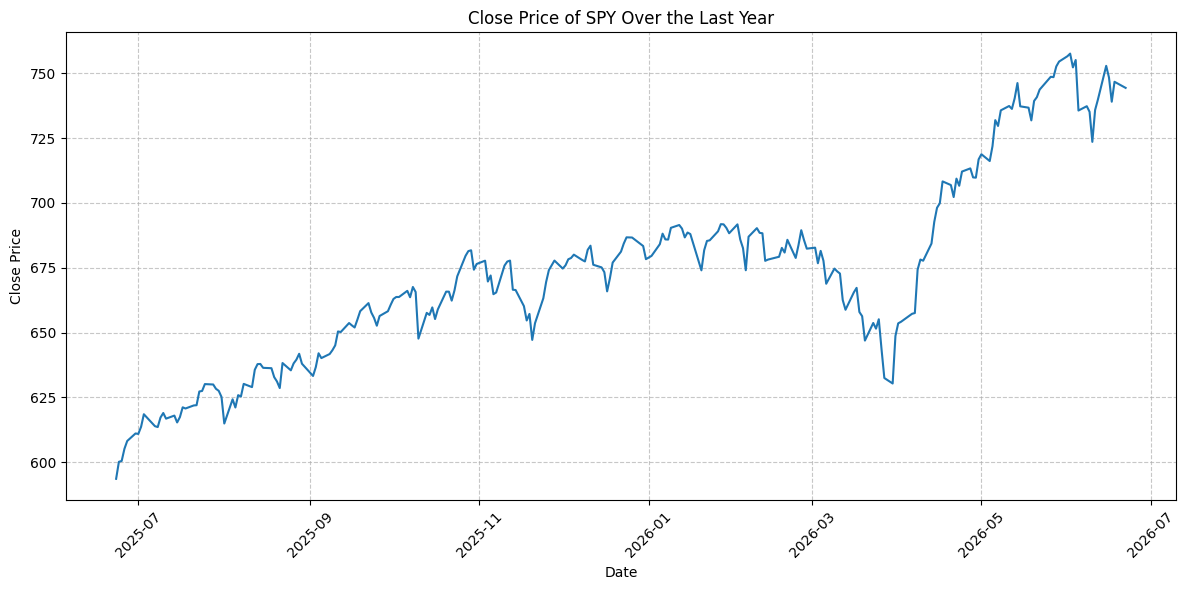

In [111]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.lineplot(x=df.index, y=df['Close'])
plt.title(f'Close Price of {ticker_input} Over the Last Year')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

[*********************100%***********************]  1 of 1 completed


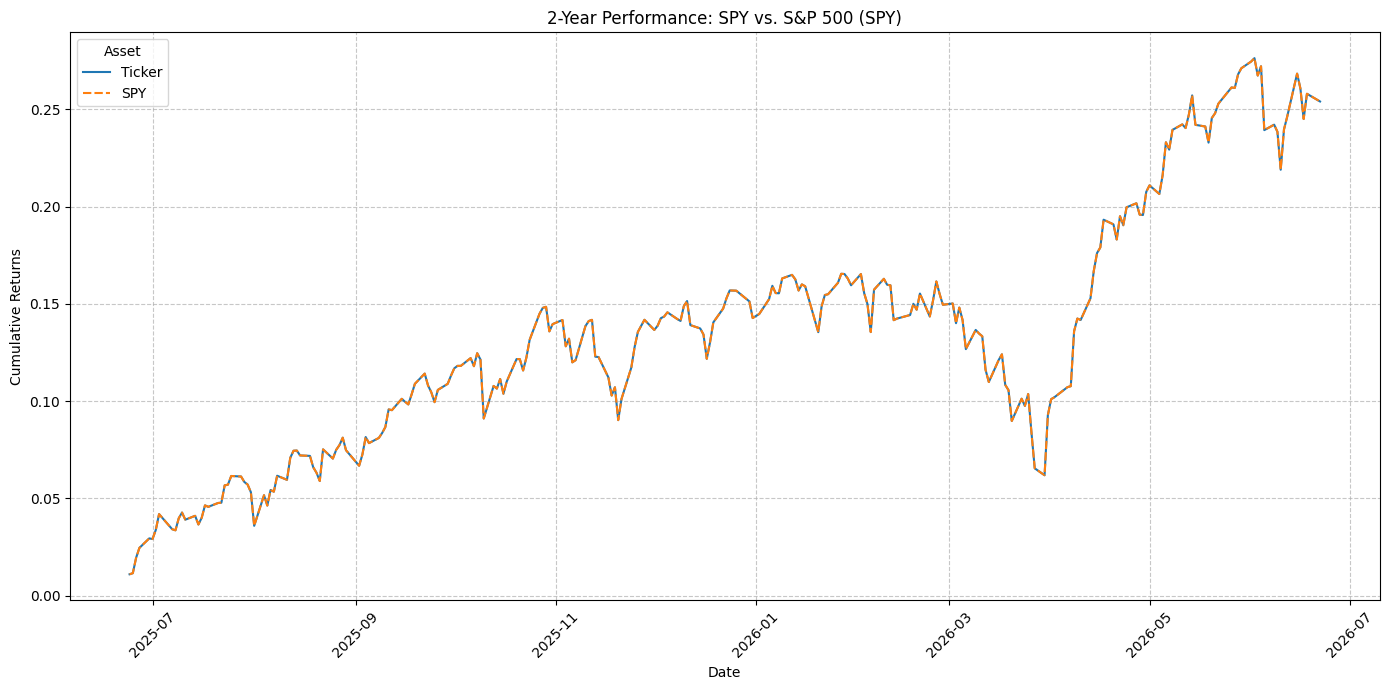

In [112]:
import matplotlib.pyplot as plt
import seaborn as sns

# Fetch SPY data for the last 2 years
spy_df = yf.download('SPY', period='2y')

# Ensure both dataframes cover the same period and align their indices
# For simplicity, we'll resample to daily and fill missing values, then trim to common dates

# Combine the 'Close' prices into a single DataFrame
# Use .squeeze() to ensure the Series are 1-dimensional
# Use .tz_localize(None) to remove timezone information and avoid TypeError
combined_df = pd.DataFrame({
    'Ticker': df['Close'].squeeze().tz_localize(None),
    'SPY': spy_df['Close'].squeeze().tz_localize(None)
}).dropna()

# Calculate daily returns
returns = combined_df.pct_change().dropna()

# Calculate cumulative returns for comparison
cumulative_returns = (1 + returns).cumprod() - 1

# Plot the comparison
plt.figure(figsize=(14, 7))
sns.lineplot(data=cumulative_returns)
plt.title(f'2-Year Performance: {ticker_input.upper()} vs. S&P 500 (SPY)')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.legend(title='Asset')
plt.tight_layout()
plt.show()

In [113]:
# @title step_artifacts
num_fig = "2" # @param {type:"string"}
step = 'DataExploration'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}
# Assuming `fig` is the last created matplotlib figure from the previous cell.
# If you save it to a variable, use that variable instead of plt.gcf().
fig = plt.gcf()
# upload_plt_to_gcs(num_fig, step, fig)

<Figure size 640x480 with 0 Axes>

In [114]:
fear_greed_index = get_fear_greed_index_alternative()
print(f"Fear & Greed Index from alternative.me: {fear_greed_index}")

Fear & Greed Index from alternative.me: N/A (Error fetching data from alternative.me: 404 Client Error: Not Found for url: https://alternative.me/markets/fear-and-greed-index/)


In [115]:
!pip install pandas_ta